# Day 4 — Feature-map inspection

Inspect activations from the tiny CNN and save feature-map galleries.


## Load the trained tiny CNN

This cell recreates the same tiny CNN architecture used in Day 3, then fills it with the learned weights from `models/tiny_cifar10_cnn.pth`.

`checkpoint["model_state_dict"]` contains the trained layer weights. `net.eval()` switches the model into inspection mode, which is the right mode when we are running images through the model without training it.


In [24]:
from collections.abc import Callable

import torch

from cnn_feature_map_lab.paths import project_path
from cnn_feature_map_lab.tiny_cnn import TinyCifar10Cnn

checkpoint_path = project_path("models", "tiny_cifar10_cnn.pth")
checkpoint = torch.load(checkpoint_path, map_location="cpu")

net = TinyCifar10Cnn()
net.load_state_dict(checkpoint["model_state_dict"])
net.eval()

print(checkpoint.keys())
print(f"mean: {checkpoint['normalize_mean']}")
print(f"std: {checkpoint['normalize_std']}")
net

dict_keys(['model_state_dict', 'optimizer_state_dict', 'batch_size', 'num_workers', 'num_epochs', 'print_every', 'learning_rate', 'momentum', 'normalize_mean', 'normalize_std', 'classes', 'train_loss_history', 'final_train_loss'])
mean: (0.5, 0.5, 0.5)
std: (0.5, 0.5, 0.5)


TinyCifar10Cnn(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

## Register hooks for intermediate activations

This cell prepares a dictionary called `activations` and attaches forward hooks to `conv1` and `conv2`.

A forward hook is a small function PyTorch runs when a chosen layer produces its output. Here the hook saves each layer output with `detach().cpu()`, so we keep the activation tensor for inspection without keeping the training graph.


In [25]:
activations: dict[str, torch.Tensor] = {}


def save_activation(name: str) -> Callable:
    def hook(module: torch.nn.Module, inputs: tuple[torch.Tensor, ...], output: torch.Tensor) -> None:
        activations[name] = output.detach().cpu()

    return hook


hooks = [
    net.conv1.register_forward_hook(save_activation("conv1")),
    net.conv2.register_forward_hook(save_activation("conv2")),
]

## Recreate the CIFAR-10 test input pipeline

This cell rebuilds the same image preprocessing recipe that the tiny CNN saw during training.

The transform converts CIFAR-10 images into tensors, scales pixels to floating-point values, and normalizes them with the saved `normalize_mean` and `normalize_std`. The DataLoader then groups examples into a small batch shaped `[batch, channels, height, width]`.


In [26]:
import torchvision
from torchvision.transforms import v2

BATCH_SIZE: int = checkpoint["batch_size"]
NUM_WORKERS: int = checkpoint["num_workers"]
NORMALIZE_MEAN: tuple[float, float, float] = checkpoint["normalize_mean"]
NORMALIZE_STD: tuple[float, float, float] = checkpoint["normalize_std"]

transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
    ]
)

test_set = torchvision.datasets.CIFAR10(
    root=str(project_path("data")),
    train=False,
    download=True,
    transform=transform,
)

test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

images, labels = next(iter(test_loader))

print("images:", images.shape)
print("labels:", labels.shape)

images: torch.Size([4, 3, 32, 32])
labels: torch.Size([4])


## Choose a clearer non-cat example

This cell measures per-class accuracy for the current checkpoint and chooses the strongest class that is not `cat`.

The goal is not to chase accuracy. We choose a class the tiny model handles better so the feature maps are less likely to come from a confusing or wrong prediction. For this checkpoint, the best non-cat class is usually `ship`.


In [27]:
accuracy_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=256,
    shuffle=False,
    num_workers=0,
)
class_names: tuple[str, ...] = tuple(checkpoint["classes"])

correct_by_class: dict[str, int] = {class_name: 0 for class_name in class_names}
total_by_class: dict[str, int] = {class_name: 0 for class_name in class_names}

with torch.no_grad():
    for batch_images, batch_labels in accuracy_loader:
        batch_outputs = net(batch_images)
        batch_predictions = batch_outputs.argmax(dim=1)

        for label, prediction in zip(batch_labels, batch_predictions, strict=True):
            class_name = class_names[label.item()]
            total_by_class[class_name] += 1
            correct_by_class[class_name] += int(label.item() == prediction.item())

class_accuracy: dict[str, float] = {
    class_name: 100 * correct_by_class[class_name] / total_by_class[class_name] for class_name in class_names
}

for class_name, accuracy in sorted(class_accuracy.items(), key=lambda item: item[1], reverse=True):
    print(f"{class_name:5s}: {accuracy:5.1f}%")

TARGET_CLASS = max(
    (class_name for class_name in class_names if class_name != "cat"),
    key=lambda class_name: class_accuracy[class_name],
)
print(f"Choosing target class: {TARGET_CLASS}")

ship :  73.9%
truck:  73.5%
horse:  64.2%
frog :  61.5%
car  :  58.6%
plane:  56.2%
dog  :  47.7%
deer :  41.2%
bird :  39.4%
cat  :  34.3%
Choosing target class: ship


## Run one correctly predicted target image and inspect activation shapes

This cell searches the test set for one image from the chosen target class that the model predicts correctly.

`outputs` has shape `[1, 10]`, meaning one image and 10 raw CIFAR-10 class scores. The feature-map tensors are in `activations["conv1"]` and `activations["conv2"]`; these are the tensors we will visualize.


In [28]:
target_class_index = class_names.index(TARGET_CLASS)
selected_image: torch.Tensor | None = None
selected_label: int | None = None
selected_outputs: torch.Tensor | None = None

with torch.no_grad():
    for candidate_image, candidate_label in test_set:
        if candidate_label != target_class_index:
            continue

        candidate_batch = candidate_image.unsqueeze(0)
        candidate_outputs = net(candidate_batch)
        candidate_prediction = candidate_outputs.argmax(dim=1).item()

        if candidate_prediction == target_class_index:
            selected_image = candidate_batch
            selected_label = candidate_label
            selected_outputs = candidate_outputs
            break

if selected_image is None or selected_label is None or selected_outputs is None:
    raise ValueError(f"Could not find a correctly predicted {TARGET_CLASS!r} example.")

images = selected_image
labels = torch.tensor([selected_label])
outputs = selected_outputs
predicted_label = outputs.argmax(dim=1).item()

print(f"target class: {TARGET_CLASS}")
print(f"true label: {class_names[labels[0].item()]}")
print(f"predicted label: {class_names[predicted_label]}")
print("model output:", outputs.shape)
print("conv1 activation:", activations["conv1"].shape)
print("conv2 activation:", activations["conv2"].shape)

target class: ship
true label: ship
predicted label: ship
model output: torch.Size([1, 10])
conv1 activation: torch.Size([1, 6, 28, 28])
conv2 activation: torch.Size([1, 16, 10, 10])


## Display the image under test

This cell shows the exact image whose feature maps will be displayed next.

The DataLoader gives the model a normalized tensor, so this cell first unnormalizes the image back toward display values in the `0..1` range. Keeping the original image beside the activation grids makes it easier to ask what each feature map is responding to.


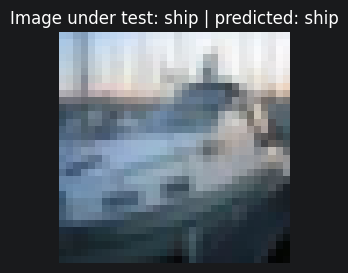

In [29]:
import matplotlib.pyplot as plt

image_index = 0

mean = torch.tensor(NORMALIZE_MEAN).view(3, 1, 1)
std = torch.tensor(NORMALIZE_STD).view(3, 1, 1)
image_to_show = (images[image_index].detach().cpu() * std + mean).clamp(0, 1)
label_name = class_names[labels[image_index].item()]
predicted_name = class_names[outputs.argmax(dim=1)[image_index].item()]

plt.figure(figsize=(3, 3))
plt.imshow(image_to_show.permute(1, 2, 0).numpy())
plt.title(f"Image under test: {label_name} | predicted: {predicted_name}")
plt.axis("off")
plt.show()

## Save and display feature-map grids

This cell turns selected activation channels into visible feature maps.

Each channel is normalized separately for display, then placed into a Matplotlib grid. `fig.savefig(...)` writes the grid under `outputs/day04_tiny_cnn_activations/`, and `plt.show()` displays the same grid inline in the notebook for immediate inspection.


Saved conv1 feature map grid to C:\Users\giloz\dev\cnn-feature-map-lab\outputs\day04_tiny_cnn_activations\conv1_feature_maps.png


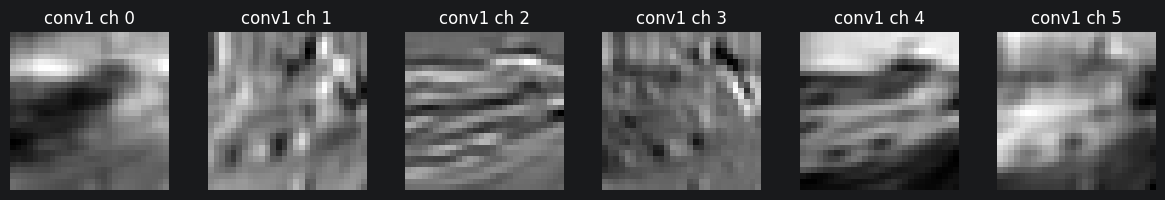

Saved conv2 feature map grid to C:\Users\giloz\dev\cnn-feature-map-lab\outputs\day04_tiny_cnn_activations\conv2_feature_maps.png


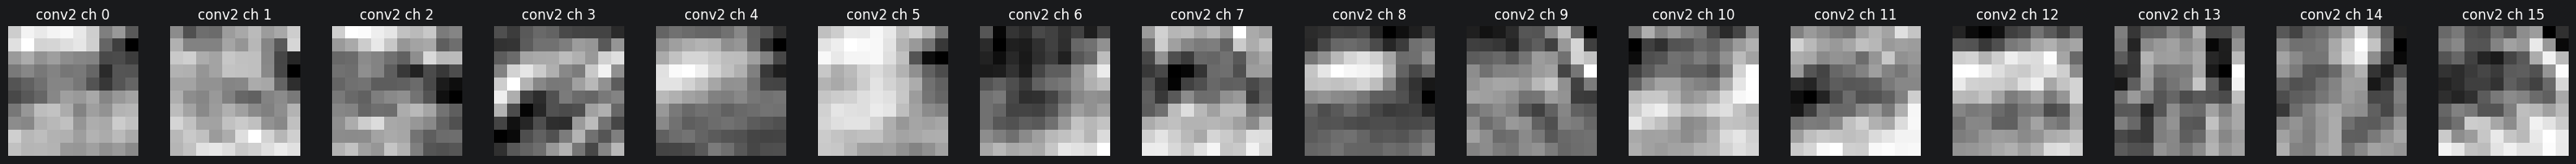

In [30]:
import matplotlib.pyplot as plt

from cnn_feature_map_lab.visualization import normalize_feature_map

OUTPUT_DIR = project_path("outputs", "day04_tiny_cnn_activations")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def save_and_show_feature_map_grid(
    activation: torch.Tensor,
    layer_name: str,
    max_channels: int,
) -> None:
    feature_maps = activation[image_index]
    num_channels = min(max_channels, feature_maps.shape[0])

    fig, axes = plt.subplots(1, num_channels, figsize=(num_channels * 2, 2))

    for channel_index, axis in enumerate(axes):
        feature_map = normalize_feature_map(feature_maps[channel_index])
        axis.imshow(feature_map, cmap="gray")
        axis.set_title(f"{layer_name} ch {channel_index}")
        axis.axis("off")

    output_path = OUTPUT_DIR / f"{layer_name}_feature_maps.png"
    fig.tight_layout()
    fig.savefig(output_path, dpi=150)

    print(f"Saved {layer_name} feature map grid to {output_path}")
    plt.show()
    plt.close(fig)


save_and_show_feature_map_grid(activations["conv1"], "conv1", max_channels=6)
save_and_show_feature_map_grid(activations["conv2"], "conv2", max_channels=16)

## Reflection

Some `conv1` feature maps are easier to relate to the input image because they still line up with visible image structure, such as edges, contrast changes, or broad foreground/background boundaries. For the selected non-cat example, at least one feature map seems to respond near an edge-like region, and another seems stronger around exterior/background areas rather than only on the object itself.

The `conv2` feature maps are harder to explain in direct human terms. They are smaller spatial grids and combine information from the earlier `conv1` feature maps, so they look more abstract and less like clean object-part detectors. I should be careful not to claim that a channel definitely means "ship," "hull," or another named part; a feature map can be useful to the network even when I cannot give it a simple human label.

What seems clearer is the difference in level: early feature maps are more visually local and sometimes edge/contrast-like, while later feature maps are more mixed and model-specific. One remaining question is how to tell whether a hard-to-name feature map is genuinely useful for the final prediction or just visually noisy to me.
